Бинарное изображение сохранено, размер: (400, 600)


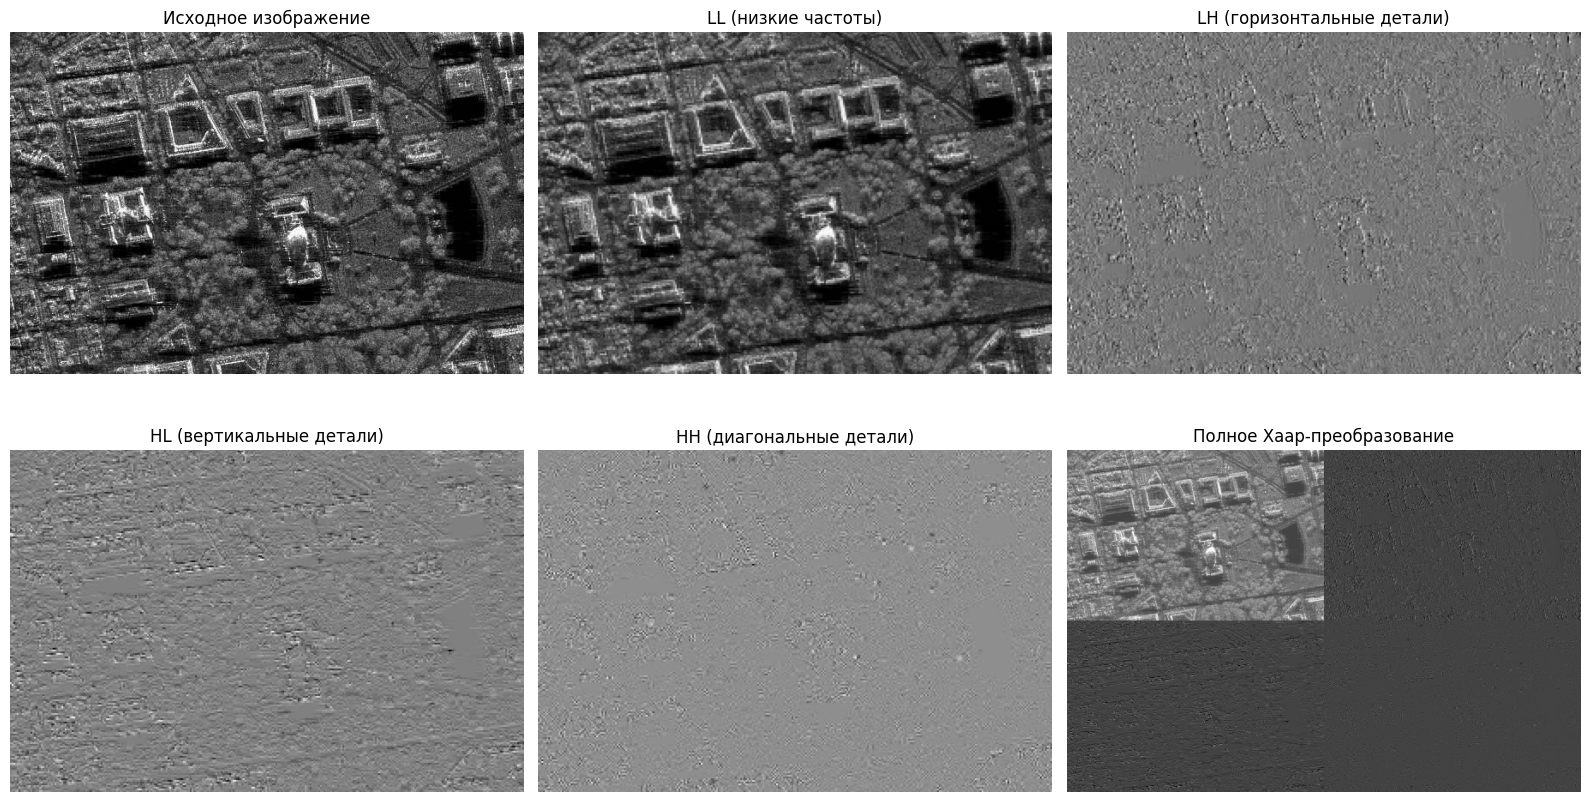

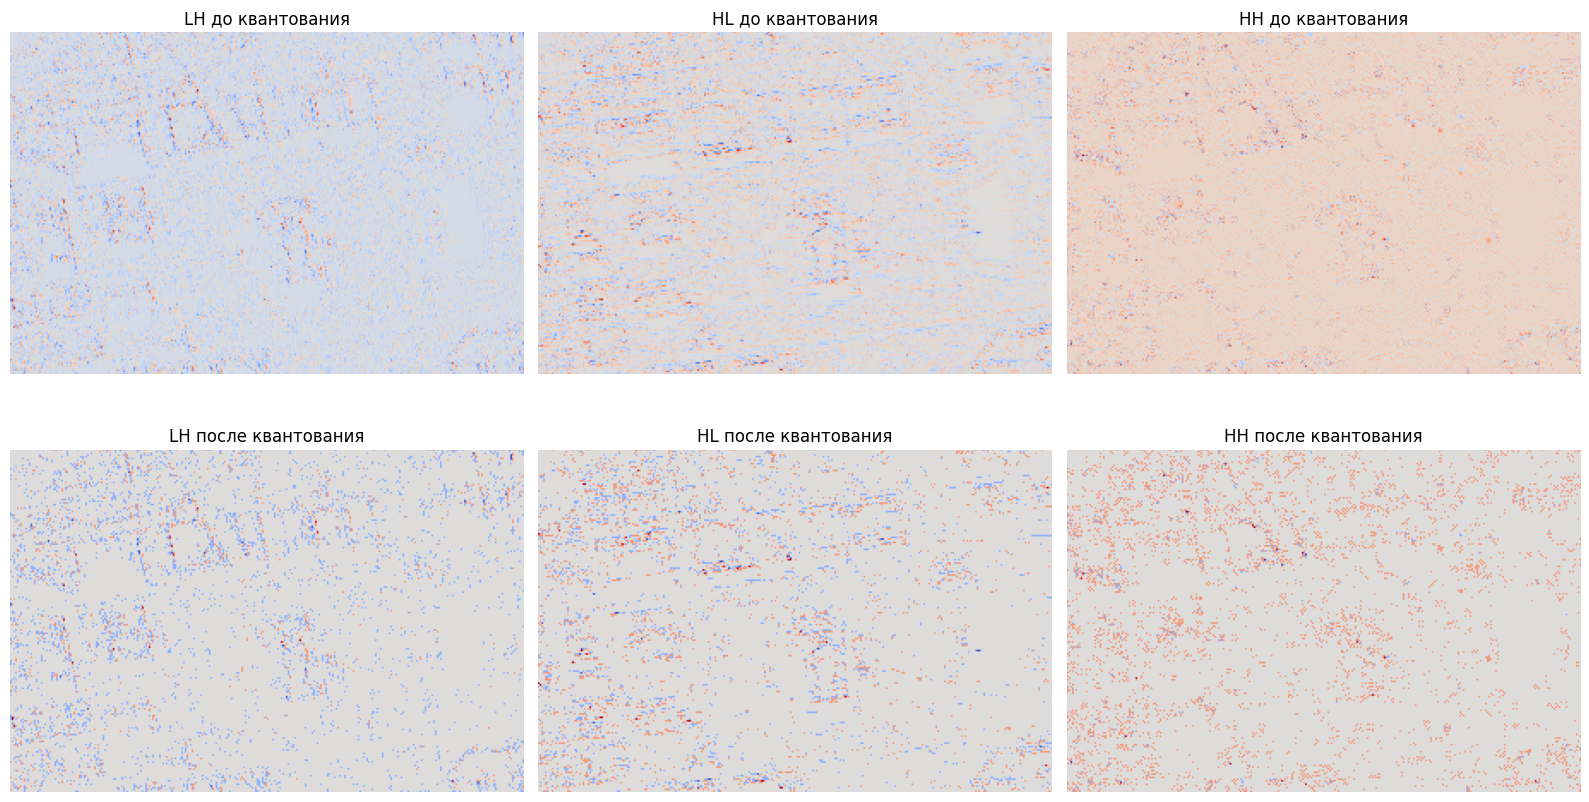

Данные Хаара сохранены в файл haar_encoded.txt

Размер бинарного изображения: 528542 байт
Размер после Хаара + RLE: 290114 байт
Коэффициент сжатия: 1.82


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Загрузка и бинаризация изображения
# =========================================================

src_img = cv2.imread("sar_1_gray.jpg")
gray_img = cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY)

_, binary = cv2.threshold(gray_img, 128, 255, cv2.THRESH_BINARY)

with open("binary_image.txt", "w") as f:
    for row in binary:
        f.write(" ".join(map(str, row)) + "\n")

print(f"Бинарное изображение сохранено, размер: {binary.shape}")

# =========================================================
# 2. Одноуровневое преобразование Хаара
# =========================================================

def haar_wavelet(img):
    img = img.astype(np.float32)
    h, w = img.shape

    row_buffer = np.zeros_like(img)

    for i in range(h):
        k = 0
        for j in range(0, w - 1, 2):
            row_buffer[i, k] = (img[i, j] + img[i, j + 1]) / 2
            row_buffer[i, k + w // 2] = (img[i, j] - img[i, j + 1]) / 2
            k += 1

    col_buffer = np.zeros_like(row_buffer)

    for j in range(w):
        k = 0
        for i in range(0, h - 1, 2):
            col_buffer[k, j] = (row_buffer[i, j] + row_buffer[i + 1, j]) / 2
            col_buffer[k + h // 2, j] = (row_buffer[i, j] - row_buffer[i + 1, j]) / 2
            k += 1

    ll = col_buffer[:h // 2, :w // 2]
    lh = col_buffer[:h // 2, w // 2:]
    hl = col_buffer[h // 2:, :w // 2]
    hh = col_buffer[h // 2:, w // 2:]

    return ll, lh, hl, hh, col_buffer


ll, lh, hl, hh, haar_full = haar_wavelet(gray_img)

# =========================================================
# 3. Отображение результатов Хаара
# =========================================================

plt.figure(figsize=(16, 9))

images = [
    (gray_img, "Исходное изображение"),
    (ll, "LL (низкие частоты)"),
    (lh, "LH (горизонтальные детали)"),
    (hl, "HL (вертикальные детали)"),
    (hh, "HH (диагональные детали)"),
    (haar_full, "Полное Хаар-преобразование")
]

for i, (img, title) in enumerate(images):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# 4. Квантование и восстановление
# =========================================================

def quantize_uniform(data, levels):
    min_v = data.min()
    max_v = data.max()
    step = (max_v - min_v) / levels if max_v != min_v else 1
    q = np.round((data - min_v) / step).astype(int)
    return q, min_v, step


def dequantize_uniform(q, min_v, step):
    return min_v + q * step


levels = 4

lh_q, lh_min, lh_step = quantize_uniform(lh, levels)
hl_q, hl_min, hl_step = quantize_uniform(hl, levels)
hh_q, hh_min, hh_step = quantize_uniform(hh, levels)

lh_rec = dequantize_uniform(lh_q, lh_min, lh_step)
hl_rec = dequantize_uniform(hl_q, hl_min, hl_step)
hh_rec = dequantize_uniform(hh_q, hh_min, hh_step)

# =========================================================
# 5. Сравнение до и после квантования
# =========================================================

plt.figure(figsize=(16, 9))

pairs = [
    (lh, lh_rec, "LH"),
    (hl, hl_rec, "HL"),
    (hh, hh_rec, "HH")
]

for i, (orig, rec, name) in enumerate(pairs):
    plt.subplot(2, 3, i + 1)
    plt.imshow(orig, cmap="coolwarm")
    plt.title(f"{name} до квантования")
    plt.axis("off")

    plt.subplot(2, 3, i + 4)
    plt.imshow(rec, cmap="coolwarm")
    plt.title(f"{name} после квантования")
    plt.axis("off")

plt.tight_layout()
plt.show()

# =========================================================
# 6. RLE-кодирование
# =========================================================

def rle_encode(array):
    flat = array.flatten()
    encoded = []
    count = 1

    for i in range(1, len(flat)):
        if flat[i] == flat[i - 1]:
            count += 1
        else:
            encoded.append((flat[i - 1], count))
            count = 1

    encoded.append((flat[-1], count))
    return encoded


lh_rle = rle_encode(lh_q)
hl_rle = rle_encode(hl_q)
hh_rle = rle_encode(hh_q)

# =========================================================
# 7. Сохранение данных в файл
# =========================================================

with open("haar_encoded.txt", "w") as f:
    np.savetxt(f, ll.astype(int), fmt="%d")
    f.write("\n")

    for name, data in [("LH", lh_rle), ("HL", hl_rle), ("HH", hh_rle)]:
        f.write(f"[{name}]\n")
        for value, count in data:
            f.write(f"{value} {count}\n")
        f.write("\n")

print("Данные Хаара сохранены в файл haar_encoded.txt")

# =========================================================
# 8. Оценка степени сжатия
# =========================================================

with open("binary_image.txt", "r") as f:
    size_original = len(f.read().encode("utf-8"))

with open("haar_encoded.txt", "r") as f:
    size_compressed = len(f.read().encode("utf-8"))

print(f"\nРазмер бинарного изображения: {size_original} байт")
print(f"Размер после Хаара + RLE: {size_compressed} байт")
print(f"Коэффициент сжатия: {size_original / size_compressed:.2f}")
